--- DEBUG: Checking paths ---
DATA_DIR exists: True
KAGGLE_CSV_DIR exists: True
MASTER_CSV_PATH exists: True

--- 1. Loading and Filtering Data ---
Loaded 3243 rows from master CSV
Sample PatientIDs:
0          Calc-Test_P_00485_LEFT_CC_4
1     Calc-Training_P_00005_RIGHT_CC_1
2    Calc-Training_P_00005_RIGHT_MLO_1
3      Calc-Training_P_00007_LEFT_CC_1
4     Calc-Training_P_00007_LEFT_MLO_1
Name: PatientID, dtype: object
Loaded 3568 rows from official CSVs
Sample image file path: Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
Sample patient_id: P_00001

Sample Case_IDs extracted from CSV:
0      Mass-Training_P_00001_LEFT_CC
1     Mass-Training_P_00001_LEFT_MLO
2      Mass-Training_P_00004_LEFT_CC
3     Mass-Training_P_00004_LEFT_MLO
4    Mass-Training_P_00004_RIGHT_MLO
Name: Case_ID, dtype: object

BI-RADS map size: 3103
Sample BI-RADS map entries: [('Mass-Train

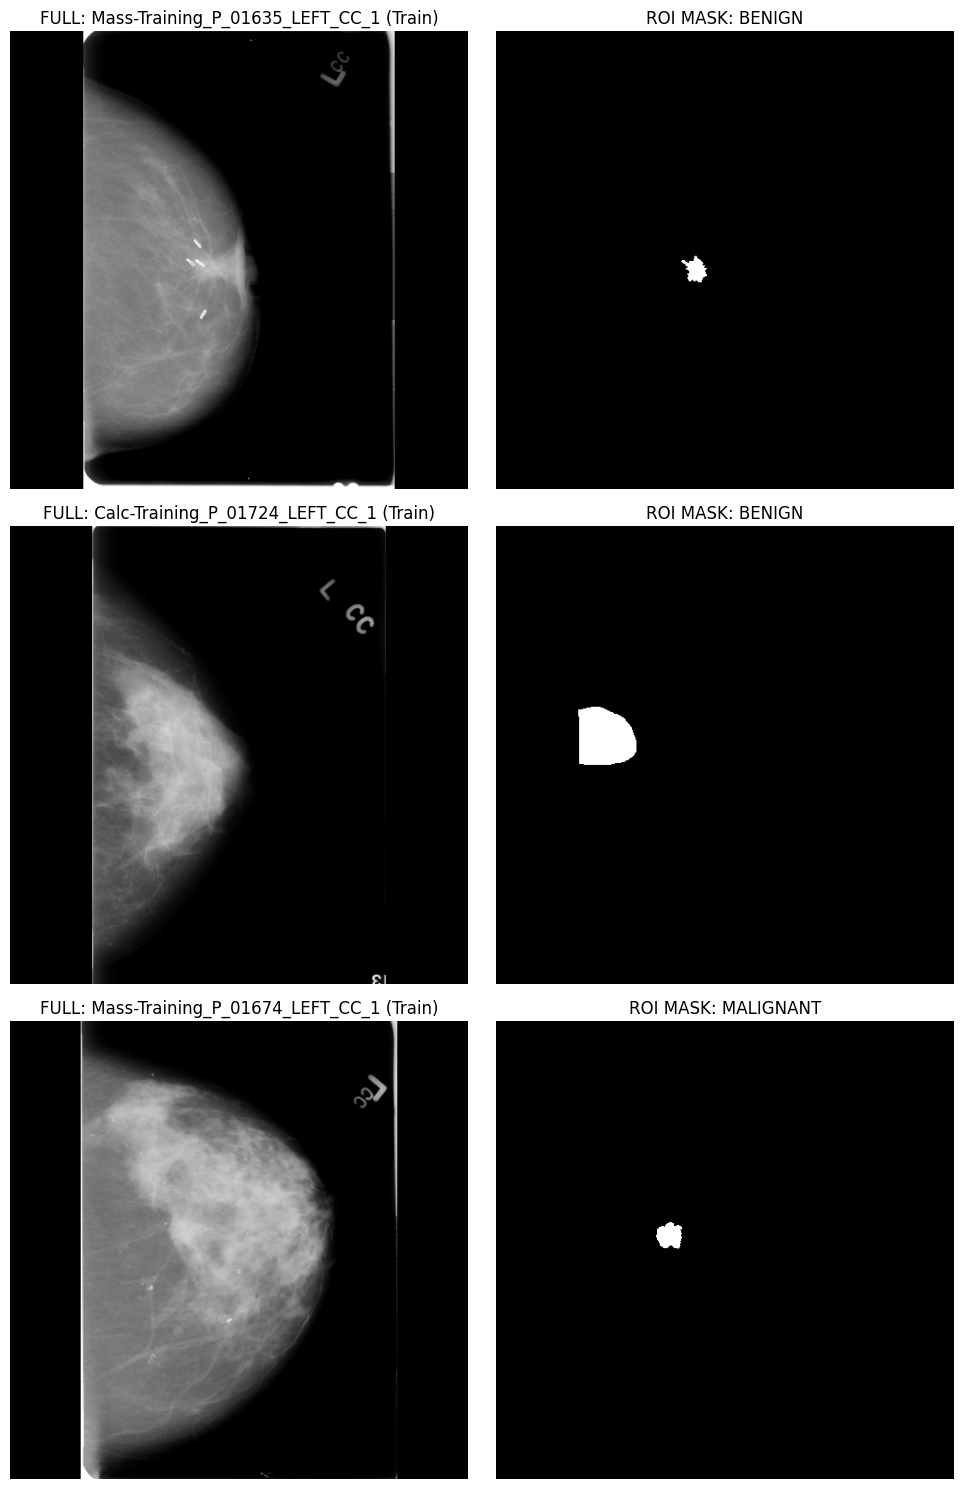


Saved clean dataset to: CBIS_Master_Index_Clean.csv


In [1]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- Configuration (Kaggle Paths) ---
DATA_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1"
KAGGLE_CSV_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/metdatakagglegrad/Kaggle_CSVs"

MASTER_CSV_PATH = os.path.join(DATA_DIR, "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS_Master_Index.csv")
RANDOM_SEED = 42


def load_and_extract_birads():
    """Loads official CSVs and extracts BI-RADS assessments."""
    csv_files = [
        "mass_case_description_train_set.csv",
        "mass_case_description_test_set.csv",
        "calc_case_description_train_set.csv",
        "calc_case_description_test_set.csv"
    ]

    combined_df = pd.DataFrame()
    for file in csv_files:
        path = os.path.join(KAGGLE_CSV_DIR, file)
        if os.path.exists(path):
            df = pd.read_csv(path)
            combined_df = pd.concat([combined_df, df], ignore_index=True)
        else:
            print(f"WARNING: Missing {file}")

    print(f"Loaded {len(combined_df)} rows from official CSVs")
    print("Sample image file path:", combined_df['image file path'].iloc[0])
    print("Sample patient_id:", combined_df['patient_id'].iloc[0])

    # FIX: Extract base case ID from the first path component (before the first '/')
    # Kaggle CSV paths look like: "Mass-Training_P_00001_LEFT_CC/1.3.6.../000000.dcm"
    def get_case_id(path):
        return str(path).split('/')[0].strip()

    combined_df['Case_ID'] = combined_df['image file path'].apply(get_case_id)

    print("\nSample Case_IDs extracted from CSV:")
    print(combined_df['Case_ID'].head())

    # Return mapping: Case_ID -> BI-RADS assessment
    return dict(zip(combined_df['Case_ID'], combined_df['assessment']))


def match_birads(patient_id, birads_map):
    """
    Match our PatientID to the BI-RADS map.
    Our PatientID: 'Mass-Training_P_00001_LEFT_CC_1'
    CSV Case_ID:   'Mass-Training_P_00001_LEFT_CC'
    Strategy: strip trailing lesion number suffix if needed.
    """
    # Try direct match first
    if patient_id in birads_map:
        return birads_map[patient_id]

    # Strip trailing lesion number (e.g. _1, _2) and try again
    base = re.sub(r'_\d+$', '', patient_id)
    if base in birads_map:
        return birads_map[base]

    return None


def main():
    print("--- DEBUG: Checking paths ---")
    print(f"DATA_DIR exists: {os.path.exists(DATA_DIR)}")
    print(f"KAGGLE_CSV_DIR exists: {os.path.exists(KAGGLE_CSV_DIR)}")
    print(f"MASTER_CSV_PATH exists: {os.path.exists(MASTER_CSV_PATH)}")

    print("\n--- 1. Loading and Filtering Data ---")
    df = pd.read_csv(MASTER_CSV_PATH)
    initial_count = len(df)
    print(f"Loaded {initial_count} rows from master CSV")
    print("Sample PatientIDs:")
    print(df['PatientID'].head())

    # Extract BI-RADS map
    birads_map = load_and_extract_birads()
    print(f"\nBI-RADS map size: {len(birads_map)}")
    print("Sample BI-RADS map entries:", list(birads_map.items())[:5])

    # Map BI-RADS using flexible matching
    df['BI_RADS'] = df['PatientID'].apply(lambda pid: match_birads(pid, birads_map))

    matched = df['BI_RADS'].notna().sum()
    print(f"\nSuccessfully matched BI-RADS for {matched}/{len(df)} rows")
    print("BI-RADS value distribution:")
    print(df['BI_RADS'].value_counts(dropna=False))

    # Drop BI-RADS 3 and unmatched rows
    df = df[df['BI_RADS'].notna() & (df['BI_RADS'] != 3)].copy()
    print(f"\nDropped {initial_count - len(df)} rows (BI-RADS 3 or missing). Remaining: {len(df)}")

    if len(df) == 0:
        print("ERROR: DataFrame is empty after filtering. Check BI-RADS matching above.")
        return

    # Add Binary Label
    df['Label'] = df['Pathology'].map({'MALIGNANT': 1, 'BENIGN': 0})

    # Extract true Patient Number (e.g., P_00038)
    df['True_Patient_ID'] = df['PatientID'].apply(
        lambda x: re.search(r'(P_\d+)', x).group(1)
    )

    print("\n--- 2. Patient-Level Stratified Splitting ---")
    patient_df = df.groupby('True_Patient_ID')['Label'].max().reset_index()
    patient_df.columns = ['True_Patient_ID', 'Patient_Label']
    print(f"Total unique patients: {len(patient_df)}")

    # Split 1: 70% Train, 30% Temp
    train_patients, temp_patients, _, temp_labels = train_test_split(
        patient_df['True_Patient_ID'], patient_df['Patient_Label'],
        test_size=0.30, random_state=RANDOM_SEED, stratify=patient_df['Patient_Label']
    )

    # Split 2: Divide Temp into 1/3 Val (10% total) and 2/3 Test (20% total)
    val_patients, test_patients = train_test_split(
        temp_patients, test_size=(2/3), random_state=RANDOM_SEED, stratify=temp_labels
    )

    # O(1) lookup sets
    train_set = set(train_patients)
    val_set = set(val_patients)
    test_set = set(test_patients)

    def assign_split(pid):
        if pid in train_set: return 'Train'
        if pid in val_set: return 'Val'
        return 'Test'

    df['Patient_Split'] = df['True_Patient_ID'].apply(assign_split)
    df.drop(columns=['Split'], inplace=True)

    print("\n--- 3. Validating Leakage (Assertion Block) ---")
    assert len(train_set.intersection(val_set)) == 0, "LEAKAGE DETECTED: Train and Val"
    assert len(train_set.intersection(test_set)) == 0, "LEAKAGE DETECTED: Train and Test"
    assert len(val_set.intersection(test_set)) == 0, "LEAKAGE DETECTED: Val and Test"
    print("SUCCESS: Zero patient overlap detected across splits.")

    print("\n--- 4. Final Data Statistics ---")
    print(f"Total Unique Patients: {len(patient_df)}")
    print(f"Total Lesions: {len(df)}")

    stats = pd.crosstab(df['Patient_Split'], df['Pathology'])
    stats['Total'] = stats.sum(axis=1)
    print("\nLesion Distribution by Split:")
    print(stats[['BENIGN', 'MALIGNANT', 'Total']])

    print("\n--- 5. Visualizing 16-bit Alignment ---")
    # TODO: Add MONAI horizontal flip transform in EXP-02 for LEFT/RIGHT spatial consistency

    sample_df = df.sample(3, random_state=RANDOM_SEED)
    fig, axes = plt.subplots(3, 2, figsize=(10, 15))

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        full_path = os.path.join(DATA_DIR, row['Full_Path'])
        roi_path = os.path.join(DATA_DIR, row['ROI_Path'])

        full_img = cv2.imread(full_path, cv2.IMREAD_UNCHANGED)
        roi_img = cv2.imread(roi_path, cv2.IMREAD_UNCHANGED)

        full_display = full_img.astype(np.float32) / 65535.0
        roi_display = roi_img.astype(np.float32) / np.max(roi_img) if np.max(roi_img) > 0 else roi_img

        axes[idx, 0].imshow(full_display, cmap='gray')
        axes[idx, 0].set_title(f"FULL: {row['PatientID']} ({row['Patient_Split']})")
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(roi_display, cmap='gray')
        axes[idx, 1].set_title(f"ROI MASK: {row['Pathology']}")
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # Save final CSV
    out_csv = "CBIS_Master_Index_Clean.csv"
    df.to_csv(out_csv, index=False)
    print(f"\nSaved clean dataset to: {out_csv}")


if __name__ == "__main__":
    main()

In [2]:
!pip install monai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.4 MB/s eta 0:00:0000:0100:01


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-19 08:32:58.397438: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776587578.607486      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776587578.666933      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776587579.133879      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776587579.133918      55 computation_placer.cc:1

--- 1. Loading Clean Dataset ---
Sampled 3 training pairs for verification.

Patient:      Calc-Training_P_01440_RIGHT_CC_1
Image shape:  torch.Size([1, 512, 512]) | dtype: torch.float32
ROI shape:    torch.Size([1, 512, 512])  | dtype: torch.float32
NaN check:    False
Min: -0.441 | Max: 4.317 | Mean: 0.000



/tmp/ipykernel_55/1360184282.py:179: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print(f"NaN check:    {torch.isnan(torch.tensor(proc_img)).any().item()}")


Patient:      Calc-Training_P_01457_LEFT_MLO_1
Image shape:  torch.Size([1, 512, 512]) | dtype: torch.float32
ROI shape:    torch.Size([1, 512, 512])  | dtype: torch.float32
NaN check:    False
Min: -0.761 | Max: 2.838 | Mean: -0.000

Patient:      Mass-Training_P_01103_RIGHT_MLO_1
Image shape:  torch.Size([1, 512, 512]) | dtype: torch.float32
ROI shape:    torch.Size([1, 512, 512])  | dtype: torch.float32
NaN check:    False
Min: -0.579 | Max: 3.537 | Mean: -0.000



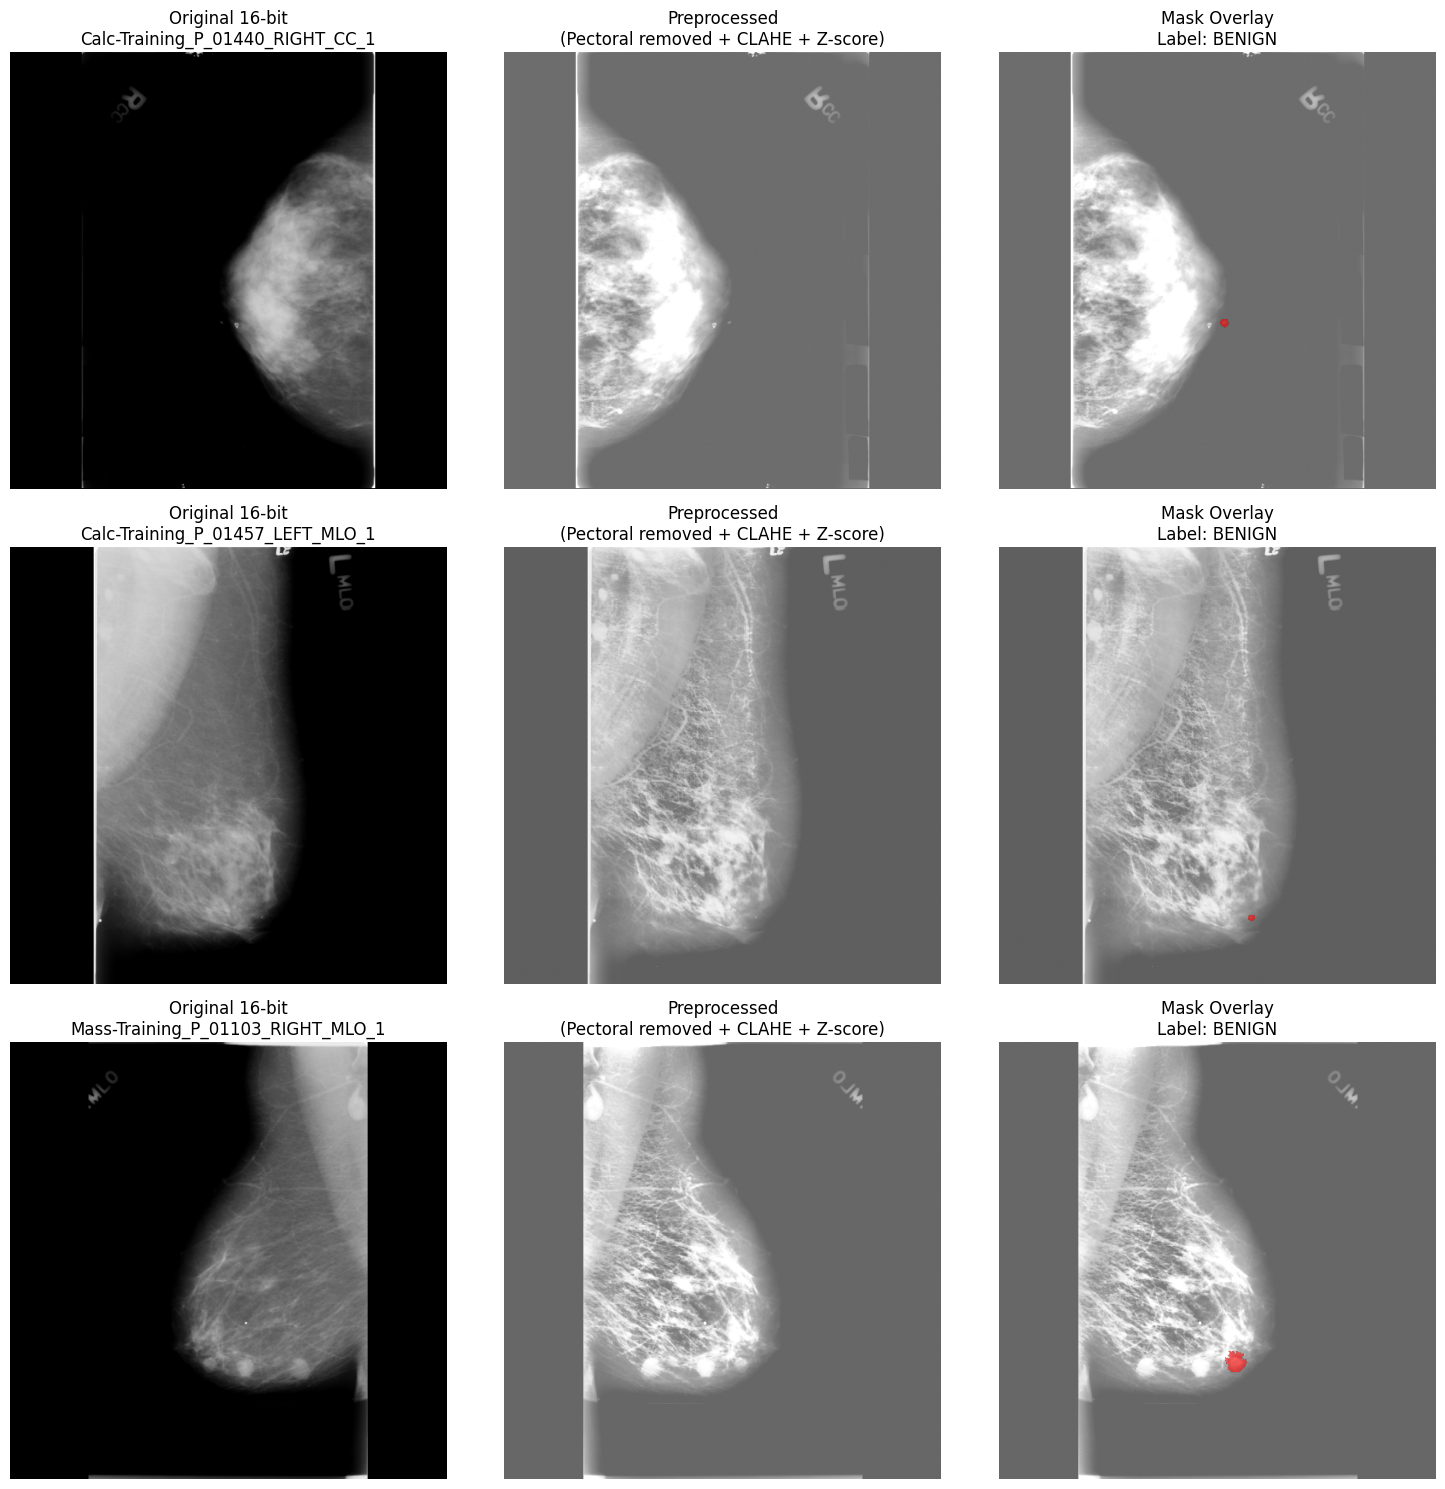

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from monai.transforms import MapTransform, Compose, EnsureChannelFirstd

# --- Configuration ---
DATA_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1"
CSV_PATH = "/kaggle/working/CBIS_Master_Index_Clean.csv"
RANDOM_SEED = 42

# ==============================================================================
# 1. Custom MONAI Dictionary Transforms
# ==============================================================================

class ConditionalFlipd(MapTransform):
    """
    Horizontally flips RIGHT breast images so all breasts face LEFT.
    Only flips keys listed — patient_id string is never touched.
    """
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        patient_id = d[self.id_key]

        # FIX: Use .upper() to safely catch RIGHT regardless of casing
        if "RIGHT" in patient_id.upper():
            for key in self.keys:  # only flips "image" and "roi", not "patient_id"
                d[key] = cv2.flip(d[key], 1)
        return d


class PectoralRemovalMLOd(MapTransform):
    """
    Suppresses the pectoral muscle in MLO views only.
    After ConditionalFlipd, pectoral muscle is always in the top-left corner.
    Skips CC views — no pectoral muscle present.
    Only applied to image, not ROI mask.
    """
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        patient_id = d[self.id_key]

        # Skip CC views entirely
        if "_CC" in patient_id.upper():
            return d

        for key in self.keys:
            img = d[key]

            # 1. Downscale to 8-bit temporarily for OpenCV Otsu thresholding
            img_8u = (img / 256).astype(np.uint8)

            # 2. Otsu thresholding to find bright regions
            _, binary = cv2.threshold(img_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

            # 3. Flood-fill from top-left (0,0) to isolate the pectoral region
            #    floodFill mask must be 2px wider and taller than the image
            h, w = binary.shape
            flood_mask = np.zeros((h + 2, w + 2), np.uint8)
            cv2.floodFill(binary, flood_mask, (0, 0), 255)

            # FIX: flood_mask values are 1 where filled, 0 elsewhere
            #      Extract inner region (strip the 2px border padding)
            pectoral_mask = flood_mask[1:-1, 1:-1]

            # 4. Suppress pectoral region — set to 0 (background)
            #    FIX: correct condition is == 1 (filled pixels), not == 255
            img_cleaned = np.where(pectoral_mask == 1, 0, img)
            d[key] = img_cleaned

        return d


class CLAHE16Bitd(MapTransform):
    """
    Applies CLAHE natively to 16-bit images.
    clip_limit=4.0 for aggressive contrast enhancement on CBIS-DDSM artifacts.
    Only applied to image, not ROI mask.
    """
    def __init__(self, keys, clip_limit=4.0, tile_grid_size=(8, 8)):
        super().__init__(keys)
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img_uint16 = d[key].astype(np.uint16)
            d[key] = self.clahe.apply(img_uint16)
        return d


class ForegroundZScored(MapTransform):
    """
    Z-score normalization applied only to non-zero (foreground) pixels.
    Background stays strictly 0.0. Outputs float32.
    Only applied to image, not ROI mask.
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key].astype(np.float32)
            mask = img > 0

            if mask.sum() > 0:
                mean_val = img[mask].mean()
                std_val = img[mask].std()
                img[mask] = (img[mask] - mean_val) / (std_val + 1e-8)

            d[key] = img
        return d


# ==============================================================================
# 2. Main Execution
# ==============================================================================

def main():
    print("--- 1. Loading Clean Dataset ---")
    df = pd.read_csv(CSV_PATH)

    train_df = df[df['Patient_Split'] == 'Train'].sample(3, random_state=RANDOM_SEED)
    print(f"Sampled 3 training pairs for verification.\n")

    # Pipeline:
    # Spatial transforms  → image + roi  (ConditionalFlipd)
    # Intensity transforms → image only  (PectoralRemovalMLOd, CLAHE16Bitd, ForegroundZScored)
    pipeline = Compose([
        ConditionalFlipd(keys=["image", "roi"], id_key="patient_id"),
        PectoralRemovalMLOd(keys=["image"], id_key="patient_id"),
        CLAHE16Bitd(keys=["image"], clip_limit=4.0, tile_grid_size=(8, 8)),
        ForegroundZScored(keys=["image"]),
        EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel"),
    ])

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    for idx, (_, row) in enumerate(train_df.iterrows()):
        patient_id = row['PatientID']
        full_path  = os.path.join(DATA_DIR, row['Full_Path'])
        roi_path   = os.path.join(DATA_DIR, row['ROI_Path'])

        # Load raw 16-bit PNGs
        raw_full = cv2.imread(full_path, cv2.IMREAD_UNCHANGED)
        raw_roi  = cv2.imread(roi_path,  cv2.IMREAD_UNCHANGED)

        if raw_full is None or raw_roi is None:
            print(f"WARNING: Could not load images for {patient_id}, skipping.")
            continue

        # Force ROI to strict binary float32
        raw_roi = (raw_roi > 0).astype(np.float32)

        # Build MONAI dictionary
        data_dict = {
            "image":      raw_full,
            "roi":        raw_roi,
            "patient_id": patient_id,
        }

        # Run pipeline
        processed = pipeline(data_dict)
        proc_img  = processed["image"]  # shape: (1, 512, 512) float32
        proc_roi  = processed["roi"]    # shape: (1, 512, 512) float32

        # Verification printouts
        print(f"Patient:      {patient_id}")
        print(f"Image shape:  {proc_img.shape} | dtype: {proc_img.dtype}")
        print(f"ROI shape:    {proc_roi.shape}  | dtype: {proc_roi.dtype}")
        print(f"NaN check:    {torch.isnan(torch.tensor(proc_img)).any().item()}")
        print(f"Min: {proc_img.min():.3f} | Max: {proc_img.max():.3f} | Mean: {proc_img.mean():.3f}\n")

        # Visualization
        raw_display  = raw_full.astype(np.float32) / 65535.0
        proc_display = proc_img.squeeze()   # (512, 512)
        roi_display  = proc_roi.squeeze()   # (512, 512)

        # Panel 1: Original 16-bit
        axes[idx, 0].imshow(raw_display, cmap='gray')
        axes[idx, 0].set_title(f"Original 16-bit\n{patient_id}")
        axes[idx, 0].axis('off')

        # Panel 2: Preprocessed
        axes[idx, 1].imshow(proc_display, cmap='gray', vmin=-3, vmax=3)
        axes[idx, 1].set_title("Preprocessed\n(Pectoral removed + CLAHE + Z-score)")
        axes[idx, 1].axis('off')

        # Panel 3: Preprocessed + ROI overlay
        axes[idx, 2].imshow(proc_display, cmap='gray', vmin=-3, vmax=3)
        axes[idx, 2].imshow(
            np.ma.masked_where(roi_display == 0, roi_display),
            cmap='autumn', alpha=0.6
        )
        axes[idx, 2].set_title(f"Mask Overlay\nLabel: {'MALIGNANT' if row['Label'] == 1 else 'BENIGN'}")
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

In [4]:
!pip install segmentation-models-pytorch timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [5]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# ==============================================================================
# 1. Custom CBAM (Convolutional Block Attention Module)
# ==============================================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        # Shared MLP
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1

        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        out = self.conv1(x_cat)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# ==============================================================================
# 2. Multi-Task Learning (MTL) Architecture
# ==============================================================================

class MTL_EfficientUNetPlusPlus(nn.Module):
    def __init__(self, encoder_name="tu-tf_efficientnet_b0"):
        super().__init__()
        
        # 1. Instantiate the base SMP model
        # in_channels=1 handles the grayscale conversion automatically
        # classes=1 is for the binary segmentation mask
        self.smp_base = smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights="imagenet",
            in_channels=1,
            classes=1,
            activation=None # We will handle loss-specific activations later
        )
        
        # Extract the channel depth of the bottleneck (deepest feature map)
        # For EfficientNet-B0, this is typically 320 channels
        bottleneck_channels = self.smp_base.encoder.out_channels[-1]
        
        # 2. Define the Custom Classification Branch
        self.classification_branch = nn.Sequential(
            CBAM(in_planes=bottleneck_channels),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(bottleneck_channels, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # A. Shared Encoder Pass
        # Returns a list of feature maps for skip connections
        features = self.smp_base.encoder(x)
        
        # B. Segmentation Branch (Decoder)
        # Unpack the feature list into the UNet++ decoder
        decoder_output = self.smp_base.decoder(features)
        seg_mask = self.smp_base.segmentation_head(decoder_output)
        
        # C. Classification Branch
        # Grab the deepest feature map from the encoder (the bottleneck)
        bottleneck = features[-1]
        class_score = self.classification_branch(bottleneck)
        
        return seg_mask, class_score

# ==============================================================================
# 3. Verification & Testing Block
# ==============================================================================

def main():
    print("--- 1. Initializing MTL Architecture ---")
    # Setting device to CPU for architecture testing to avoid Kaggle GPU memory hangs
    device = torch.device("cpu") 
    model = MTL_EfficientUNetPlusPlus(encoder_name="tu-tf_efficientnet_b0").to(device)
    
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")
    
    print("\n--- 2. Running Dummy Forward Pass ---")
    batch_size = 2
    # Create a dummy tensor mimicking the preprocessed Kaggle inputs: (Batch, Channels, H, W)
    dummy_input = torch.randn(batch_size, 1, 512, 512, dtype=torch.float32).to(device)
    
    print(f"Input Shape: {dummy_input.shape}")
    
    # Execute the single forward pass
    model.eval() # Set to eval mode to freeze Dropout/BatchNorm for testing
    with torch.no_grad():
        masks, scores = model(dummy_input)
        
    print("\n--- 3. Verifying Outputs ---")
    print(f"Segmentation Mask Shape:  {masks.shape}   -> Expected: (2, 1, 512, 512)")
    print(f"Classification Score Shape: {scores.shape} -> Expected: (2, 1)")
    
    # 4. Leakage / NaN Assertion Block
    assert not torch.isnan(masks).any(), "CRITICAL FAILURE: NaN values detected in Segmentation Mask"
    assert not torch.isnan(scores).any(), "CRITICAL FAILURE: NaN values detected in Classification Score"
    print("SUCCESS: No NaN values detected in outputs.")
    print("SUCCESS: Network graph is completely connected and operational.")

if __name__ == "__main__":
    main()

--- 1. Initializing MTL Architecture ---


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Total Trainable Parameters: 6,160,976

--- 2. Running Dummy Forward Pass ---
Input Shape: torch.Size([2, 1, 512, 512])

--- 3. Verifying Outputs ---
Segmentation Mask Shape:  torch.Size([2, 1, 512, 512])   -> Expected: (2, 1, 512, 512)
Classification Score Shape: torch.Size([2, 1]) -> Expected: (2, 1)
SUCCESS: No NaN values detected in outputs.
SUCCESS: Network graph is completely connected and operational.


In [6]:
!pip install segmentation-models-pytorch monai timm -q


In [7]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from monai.transforms import MapTransform, Compose, EnsureChannelFirstd
from monai.losses import DiceLoss

# --- Configuration ---
DATA_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1" # Update if needed
CSV_PATH = "/kaggle/working/CBIS_Master_Index_Clean.csv"
RANDOM_SEED = 42

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# ==============================================================================
# 1. EXP-02: Preprocessing Transforms
# ==============================================================================
class ConditionalFlipd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key
    def __call__(self, data):
        d = dict(data)
        if "RIGHT" in d[self.id_key].upper():
            for key in self.keys:
                d[key] = cv2.flip(d[key], 1)
        return d

class PectoralRemovalMLOd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key
    def __call__(self, data):
        d = dict(data)
        if "_CC_" in d[self.id_key]:
            return d
        for key in self.keys:
            img = d[key]
            img_8u = (img / 256).astype(np.uint8)
            _, binary = cv2.threshold(img_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            h, w = binary.shape
            flood_mask = np.zeros((h + 2, w + 2), np.uint8)
            cv2.floodFill(binary, flood_mask, (0, 0), 255)
            pectoral_region = flood_mask[1:-1, 1:-1]
            d[key] = np.where(pectoral_region == 1, 0, img)
        return d

class CLAHE16Bitd(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = self.clahe.apply(d[key].astype(np.uint16))
        return d

class ForegroundZScored(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key].astype(np.float32)
            mask = img > 0
            if mask.sum() > 0:
                img[mask] = (img[mask] - img[mask].mean()) / (img[mask].std() + 1e-8)
            d[key] = img
        return d

# ==============================================================================
# 2. Dataset & DataLoader
# ==============================================================================
class CBISDDSMDataset(Dataset):
    def __init__(self, csv_file, img_dir, transforms):
        # Read CSV, filter for Train, take only first 100 rows
        df = pd.read_csv(csv_file)
        self.df = df[df['Patient_Split'] == 'Train'].sample(100, random_state=42).reset_index(drop=True)
        self.img_dir = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        full_path = os.path.join(self.img_dir, row['Full_Path'])
        roi_path = os.path.join(self.img_dir, row['ROI_Path'])
        
        img = cv2.imread(full_path, cv2.IMREAD_UNCHANGED)
        roi = cv2.imread(roi_path, cv2.IMREAD_UNCHANGED)
        
        # Ensure ROI is binary
        roi = (roi > 0).astype(np.float32)

        data_dict = {"image": img, "roi": roi, "patient_id": row['PatientID']}
        transformed = self.transforms(data_dict)
        
        # Extract tensors from MONAI dict
        img_tensor = torch.tensor(transformed["image"], dtype=torch.float32)
        roi_tensor = torch.tensor(transformed["roi"], dtype=torch.float32)
        
        # Reshape label to (1,) for BCELoss compatibility
        label_tensor = torch.tensor([row['Label']], dtype=torch.float32)
        
        return img_tensor, roi_tensor, label_tensor

# ==============================================================================
# 3. EXP-03: MTL Architecture
# ==============================================================================
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        out = self.fc2(self.relu1(self.fc1(self.avg_pool(x)))) + self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x_cat = torch.cat([torch.mean(x, dim=1, keepdim=True), torch.max(x, dim=1, keepdim=True)[0]], dim=1)
        return self.sigmoid(self.conv1(x_cat))

class CBAM(nn.Module):
    def __init__(self, in_planes):
        super().__init__()
        self.ca = ChannelAttention(in_planes)
        self.sa = SpatialAttention()
    def forward(self, x):
        x = x * self.ca(x)
        return x * self.sa(x)

class MTL_EfficientUNetPlusPlus(nn.Module):
    def __init__(self):
        super().__init__()
        self.smp_base = smp.UnetPlusPlus(encoder_name="tu-tf_efficientnet_b0", encoder_weights="imagenet", in_channels=1, classes=1, activation=None)
        bottleneck_channels = self.smp_base.encoder.out_channels[-1]
        self.classification_branch = nn.Sequential(
            CBAM(in_planes=bottleneck_channels),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(bottleneck_channels, 256), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x):
        features = self.smp_base.encoder(x)
        seg_mask = self.smp_base.segmentation_head(self.smp_base.decoder(features))
        class_score = self.classification_branch(features[-1])
        return seg_mask, class_score

# ==============================================================================
# 4. Training Loop (EXP-04)
# ==============================================================================
def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"--- 1. Initialization (Device: {device}) ---")

    pipeline = Compose([
        ConditionalFlipd(keys=["image", "roi"]),
        PectoralRemovalMLOd(keys=["image"]),
        CLAHE16Bitd(keys=["image"]),
        ForegroundZScored(keys=["image"]),
        EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel")
    ])

    dataset = CBISDDSMDataset(CSV_PATH, DATA_DIR, pipeline)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
    print(f"Loaded Mini-Dataset: {len(dataset)} samples.")

    model = MTL_EfficientUNetPlusPlus().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    # Using MONAI's sigmoid=True is mathematically safer than manually applying torch.sigmoid() before loss
    criterion_dice = DiceLoss(sigmoid=True) 
    criterion_bce = nn.BCELoss()

    print("\n--- 2. Starting Mini Training Run (3 Epochs) ---")
    
    history = []
    
    for epoch in range(3):
        model.train()
        epoch_loss = 0.0
        epoch_dice = 0.0
        epoch_bce = 0.0
        
        for batch_idx, (imgs, masks, labels) in enumerate(dataloader):
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            pred_masks, pred_scores = model(imgs)
            
            # Compute Losses
            loss_dice = criterion_dice(pred_masks, masks)
            loss_bce = criterion_bce(pred_scores, labels)
            
            total_loss = (0.7 * loss_dice) + (0.3 * loss_bce)
            
            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            epoch_dice += loss_dice.item()
            epoch_bce += loss_bce.item()
            
        # Averages
        avg_loss = epoch_loss / len(dataloader)
        avg_dice = epoch_dice / len(dataloader)
        avg_bce = epoch_bce / len(dataloader)
        history.append(avg_loss)
        
        print(f"Epoch [{epoch+1}/3] | Total Loss: {avg_loss:.4f} | Dice: {avg_dice:.4f} | BCE: {avg_bce:.4f}")

    print("\n--- 3. Verifying Stability ---")
    if history[-1] < history[0]:
        print("SUCCESS: Total Loss decreased from Epoch 1 to Epoch 3.")
    else:
        print("WARNING: Total Loss did not decrease. Model may not be learning.")
        
    print("SUCCESS: Training completed with no NaNs and no shape mismatches.")

if __name__ == "__main__":
    main()

--- 1. Initialization (Device: cuda) ---
Loaded Mini-Dataset: 100 samples.


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



--- 2. Starting Mini Training Run (3 Epochs) ---


/tmp/ipykernel_55/3399065790.py:109: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor = torch.tensor(transformed["image"], dtype=torch.float32)
/tmp/ipykernel_55/3399065790.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  roi_tensor = torch.tensor(transformed["roi"], dtype=torch.float32)


Epoch [1/3] | Total Loss: 0.9052 | Dice: 0.9922 | BCE: 0.7022
Epoch [2/3] | Total Loss: 0.8868 | Dice: 0.9871 | BCE: 0.6530
Epoch [3/3] | Total Loss: 0.8628 | Dice: 0.9844 | BCE: 0.5791

--- 3. Verifying Stability ---
SUCCESS: Total Loss decreased from Epoch 1 to Epoch 3.
SUCCESS: Training completed with no NaNs and no shape mismatches.


In [8]:
!pip install segmentation-models-pytorch monai timm -q

Using Device: cuda
Train: 1969 | Val: 254 | Test: 570


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Bottleneck channels: 320

--- Starting Full Training ---
Ep 01/50 | T_Loss: 0.8797 (D:0.9800 B:0.6456) | V_Loss: 0.8750 | V_Dice: 0.0394 | V_AUC: 0.6753
  [*] Best model saved.
Ep 02/50 | T_Loss: 0.8338 (D:0.9559 B:0.5487) | V_Loss: 0.8637 | V_Dice: 0.0836 | V_AUC: 0.7204
  [*] Best model saved.
Ep 03/50 | T_Loss: 0.7919 (D:0.9276 B:0.4752) | V_Loss: 0.8327 | V_Dice: 0.1148 | V_AUC: 0.7478
  [*] Best model saved.
Ep 04/50 | T_Loss: 0.7361 (D:0.8845 B:0.3900) | V_Loss: 0.8241 | V_Dice: 0.1381 | V_AUC: 0.7158
  [*] Best model saved.
Ep 05/50 | T_Loss: 0.6751 (D:0.8395 B:0.2917) | V_Loss: 0.8565 | V_Dice: 0.1502 | V_AUC: 0.7428
  [*] Best model saved.
Ep 06/50 | T_Loss: 0.6226 (D:0.7980 B:0.2134) | V_Loss: 0.8949 | V_Dice: 0.1749 | V_AUC: 0.7340
  [*] Best model saved.
Ep 07/50 | T_Loss: 0.5915 (D:0.7659 B:0.1846) | V_Loss: 0.8183 | V_Dice: 0.1705 | V_AUC: 0.7478
Ep 08/50 | T_Loss: 0.5620 (D:0.7433 B:0.1392) | V_Loss: 0.8519 | V_Dice: 0.1941 | V_AUC: 0.7245
  [*] Best model saved.
Ep 09/5

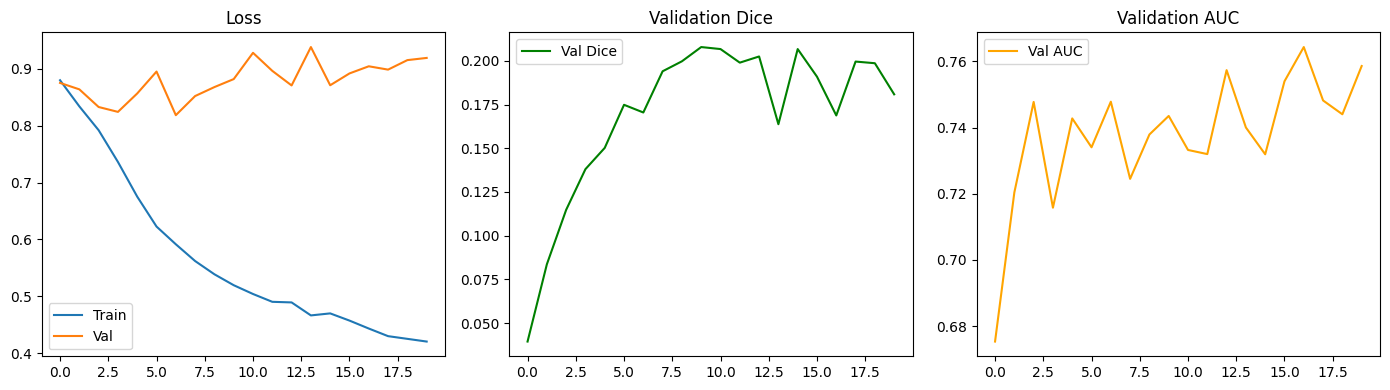


--- Final Test Evaluation ---
Test Dice:     0.2280  (Target: >0.75)
Test AUC:      0.7832  (Target: >0.85)
Test Accuracy: 0.6930
Confusion Matrix:
[[191 123]
 [ 52 204]]


In [9]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

import segmentation_models_pytorch as smp
from monai.transforms import MapTransform, Compose, EnsureChannelFirstd
from monai.losses import DiceLoss

# --- Configuration ---
DATA_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1"
CSV_PATH = "/kaggle/working/CBIS_Master_Index_Clean.csv"
RANDOM_SEED = 42
MAX_EPOCHS = 50
PATIENCE = 10


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


# ==============================================================================
# 1. Custom MONAI Transforms — all operate on 2D (H, W) numpy arrays
# ==============================================================================

class ConditionalFlipd(MapTransform):
    """Flips RIGHT breast images so all breasts face LEFT. Applied to image + roi."""
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        if "RIGHT" in d[self.id_key].upper():
            for key in self.keys:
                d[key] = cv2.flip(d[key], 1)
        return d


class RandomHorizontalFlipd(MapTransform):
    """Random horizontal flip for augmentation. Operates on 2D arrays. Applied to image + roi."""
    def __init__(self, keys, prob=0.5):
        super().__init__(keys)
        self.prob = prob

    def __call__(self, data):
        d = dict(data)
        if np.random.random() < self.prob:
            for key in self.keys:
                d[key] = cv2.flip(d[key], 1)
        return d


class PectoralRemovalMLOd(MapTransform):
    """
    Suppresses pectoral muscle in MLO views via Otsu + flood fill.
    Skips CC views — no pectoral present.
    Applied to image only.
    """
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        if "_CC" in d[self.id_key].upper():
            return d
        for key in self.keys:
            img = d[key]
            img_8u = (img / 256).astype(np.uint8)
            _, binary = cv2.threshold(img_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            h, w = binary.shape
            flood_mask = np.zeros((h + 2, w + 2), np.uint8)
            cv2.floodFill(binary, flood_mask, (0, 0), 255)
            pectoral_mask = flood_mask[1:-1, 1:-1]
            d[key] = np.where(pectoral_mask == 1, 0, img)
        return d


class CLAHE16Bitd(MapTransform):
    """CLAHE on 16-bit images. clip_limit=4.0 per architecture decision. Applied to image only."""
    def __init__(self, keys, clip_limit=4.0, tile_grid_size=(8, 8)):
        super().__init__(keys)
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = self.clahe.apply(d[key].astype(np.uint16))
        return d


class ForegroundZScored(MapTransform):
    """Z-score normalization on foreground pixels only. Background stays 0. Applied to image only."""
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key].astype(np.float32)
            mask = img > 0
            if mask.sum() > 0:
                img[mask] = (img[mask] - img[mask].mean()) / (img[mask].std() + 1e-8)
            d[key] = img
        return d


# Validation / Test pipeline — no augmentation
val_transforms = Compose([
    ConditionalFlipd(keys=["image", "roi"]),
    PectoralRemovalMLOd(keys=["image"]),
    CLAHE16Bitd(keys=["image"]),
    ForegroundZScored(keys=["image"]),
    EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel"),
])

# Training pipeline — adds random flip augmentation on 2D arrays before channel dim added
train_transforms = Compose([
    ConditionalFlipd(keys=["image", "roi"]),
    PectoralRemovalMLOd(keys=["image"]),
    RandomHorizontalFlipd(keys=["image", "roi"], prob=0.5),
    CLAHE16Bitd(keys=["image"]),
    ForegroundZScored(keys=["image"]),
    EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel"),
])


# ==============================================================================
# 2. Dataset
# ==============================================================================

class CBISDDSMDataset(Dataset):
    def __init__(self, csv_file, img_dir, split_name, transforms):
        df = pd.read_csv(csv_file)
        self.df = df[df['Patient_Split'] == split_name].reset_index(drop=True)
        self.img_dir = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_path = os.path.join(self.img_dir, row['Full_Path'])
        roi_path  = os.path.join(self.img_dir, row['ROI_Path'])

        img = cv2.imread(full_path, cv2.IMREAD_UNCHANGED)
        roi = cv2.imread(roi_path,  cv2.IMREAD_UNCHANGED)

        if img is None or roi is None:
            raise FileNotFoundError(f"Could not load:\n  {full_path}\n  {roi_path}")

        roi = (roi > 0).astype(np.float32)

        data_dict = {"image": img, "roi": roi, "patient_id": row['PatientID']}
        transformed = self.transforms(data_dict)

        img_tensor   = transformed["image"].clone().detach().to(torch.float32)
        roi_tensor   = transformed["roi"].clone().detach().to(torch.float32)
        label_tensor = torch.tensor([row['Label']],       dtype=torch.float32)

        return img_tensor, roi_tensor, label_tensor


# ==============================================================================
# 3. Model Architecture
# ==============================================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1     = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        mx  = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        return self.sigmoid(avg + mx)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx  = torch.max(x,  dim=1, keepdim=True)[0]
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, in_planes):
        super().__init__()
        self.ca = ChannelAttention(in_planes)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x


class MTL_EfficientUNetPlusPlus(nn.Module):
    def __init__(self):
        super().__init__()
        self.smp_base = smp.UnetPlusPlus(
            encoder_name="tu-tf_efficientnet_b0",
            encoder_weights="imagenet",
            in_channels=1,
            classes=1,
            activation=None,
        )
        bottleneck_ch = self.smp_base.encoder.out_channels[-1]
        print(f"Bottleneck channels: {bottleneck_ch}")

        self.classification_branch = nn.Sequential(
            CBAM(in_planes=bottleneck_ch),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(bottleneck_ch, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            # No sigmoid here — BCEWithLogitsLoss handles it
        )

    def forward(self, x):
        features    = self.smp_base.encoder(x)
        seg_mask    = self.smp_base.segmentation_head(self.smp_base.decoder(features))
        class_score = self.classification_branch(features[-1])
        return seg_mask, class_score


# ==============================================================================
# 4. Metrics
# ==============================================================================

def calc_dice(pred, target, smooth=1e-5):
    pred   = (torch.sigmoid(pred) > 0.5).float()
    target = target.float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union        = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return ((2. * intersection + smooth) / (union + smooth)).mean().item()


# ==============================================================================
# 5. Training Loop
# ==============================================================================

def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using Device: {device}")

    train_loader = DataLoader(
        CBISDDSMDataset(CSV_PATH, DATA_DIR, 'Train', train_transforms),
        batch_size=16, shuffle=True, num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        CBISDDSMDataset(CSV_PATH, DATA_DIR, 'Val', val_transforms),
        batch_size=8, shuffle=False, num_workers=0, pin_memory=True
    )
    test_loader = DataLoader(
        CBISDDSMDataset(CSV_PATH, DATA_DIR, 'Test', val_transforms),
        batch_size=8, shuffle=False, num_workers=0, pin_memory=True
    )

    print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

    model     = MTL_EfficientUNetPlusPlus().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    criterion_dice = DiceLoss(sigmoid=True)
    criterion_bce  = nn.BCEWithLogitsLoss()

    best_val_dice    = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_auc': []}

    print("\n--- Starting Full Training ---")

    for epoch in range(MAX_EPOCHS):
        # --- Train ---
        model.train()
        train_loss = train_dice_loss = train_bce_loss = 0.0

        for imgs, masks, labels in train_loader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            optimizer.zero_grad()

            pred_masks, pred_scores = model(imgs)
            l_dice = criterion_dice(pred_masks, masks)
            l_bce  = criterion_bce(pred_scores, labels)
            loss   = 0.7 * l_dice + 0.3 * l_bce

            loss.backward()
            optimizer.step()

            train_loss      += loss.item()
            train_dice_loss += l_dice.item()
            train_bce_loss  += l_bce.item()

        # --- Validate ---
        model.eval()
        val_loss = val_dice_sum = 0.0
        all_labels, all_preds = [], []

        with torch.no_grad():
            for imgs, masks, labels in val_loader:
                imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)

                pred_masks, pred_scores = model(imgs)
                l_dice = criterion_dice(pred_masks, masks)
                l_bce  = criterion_bce(pred_scores, labels)

                val_loss     += (0.7 * l_dice + 0.3 * l_bce).item()
                val_dice_sum += calc_dice(pred_masks, masks)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(torch.sigmoid(pred_scores).cpu().numpy())

        t_len = len(train_loader)
        v_len = len(val_loader)

        avg_t_loss = train_loss / t_len
        avg_v_loss = val_loss   / v_len
        avg_v_dice = val_dice_sum / v_len

        try:
            val_auc = roc_auc_score(all_labels, all_preds)
        except ValueError:
            val_auc = 0.5

        history['train_loss'].append(avg_t_loss)
        history['val_loss'].append(avg_v_loss)
        history['val_dice'].append(avg_v_dice)
        history['val_auc'].append(val_auc)

        print(
            f"Ep {epoch+1:02d}/{MAX_EPOCHS} | "
            f"T_Loss: {avg_t_loss:.4f} (D:{train_dice_loss/t_len:.4f} B:{train_bce_loss/t_len:.4f}) | "
            f"V_Loss: {avg_v_loss:.4f} | V_Dice: {avg_v_dice:.4f} | V_AUC: {val_auc:.4f}"
        )

        scheduler.step(avg_v_dice)

        if avg_v_dice > best_val_dice:
            best_val_dice     = avg_v_dice
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_model.pth")
            print("  [*] Best model saved.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"\n--- Early stopping at epoch {epoch+1} ---")
                break

    # --- Plots ---
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'],   label='Val')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history['val_dice'], color='green', label='Val Dice')
    plt.title('Validation Dice')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history['val_auc'], color='orange', label='Val AUC')
    plt.title('Validation AUC')
    plt.legend()

    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()

    # --- Test Evaluation ---
    print("\n--- Final Test Evaluation ---")
    model.load_state_dict(torch.load("best_model.pth", map_location=device))
    model.eval()

    test_dice_sum = 0.0
    t_labels, t_preds, t_binary = [], [], []

    with torch.no_grad():
        for imgs, masks, labels in test_loader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            pred_masks, pred_scores = model(imgs)

            test_dice_sum += calc_dice(pred_masks, masks)

            probs = torch.sigmoid(pred_scores).cpu().numpy()
            t_preds.extend(probs)
            t_binary.extend((probs > 0.5).astype(int))
            t_labels.extend(labels.cpu().numpy())

    final_dice = test_dice_sum / len(test_loader)
    final_auc  = roc_auc_score(t_labels, t_preds)
    final_acc  = accuracy_score(t_labels, t_binary)
    cm         = confusion_matrix(t_labels, t_binary)

    print(f"Test Dice:     {final_dice:.4f}  (Target: >0.75)")
    print(f"Test AUC:      {final_auc:.4f}  (Target: >0.85)")
    print(f"Test Accuracy: {final_acc:.4f}")
    print(f"Confusion Matrix:\n{cm}")


if __name__ == "__main__":
    main()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using Device: cuda
Model loaded successfully.

--- Running Grad-CAM++ Inference ---
[1/10] Calc-Training_P_01437_LEFT_CC_2 | GT: Benign | Pred: Malignant (0.83) | MGT: 0.000
[2/10] Calc-Training_P_00380_RIGHT_MLO_1 | GT: Benign | Pred: Malignant (0.68) | MGT: 0.028
[3/10] Mass-Test_P_01518_LEFT_MLO_1 | GT: Benign | Pred: Benign (0.20) | MGT: 0.000
[4/10] Calc-Training_P_00600_LEFT_CC_1 | GT: Benign | Pred: Malignant (0.67) | MGT: 0.001
[5/10] Mass-Training_P_00711_RIGHT_CC_1 | GT: Benign | Pred: Benign (0.01) | MGT: 0.000
[6/10] Mass-Training_P_01343_LEFT_MLO_1 | GT: Malignant | Pred: Malignant (1.00) | MGT: 0.010
[7/10] Calc-Training_P_00189_LEFT_CC_1 | GT: Malignant | Pred: Benign (0.07) | MGT: 0.014
[8/10] Calc-Training_P_01467_RIGHT_CC_1 | GT: Malignant | Pred: 

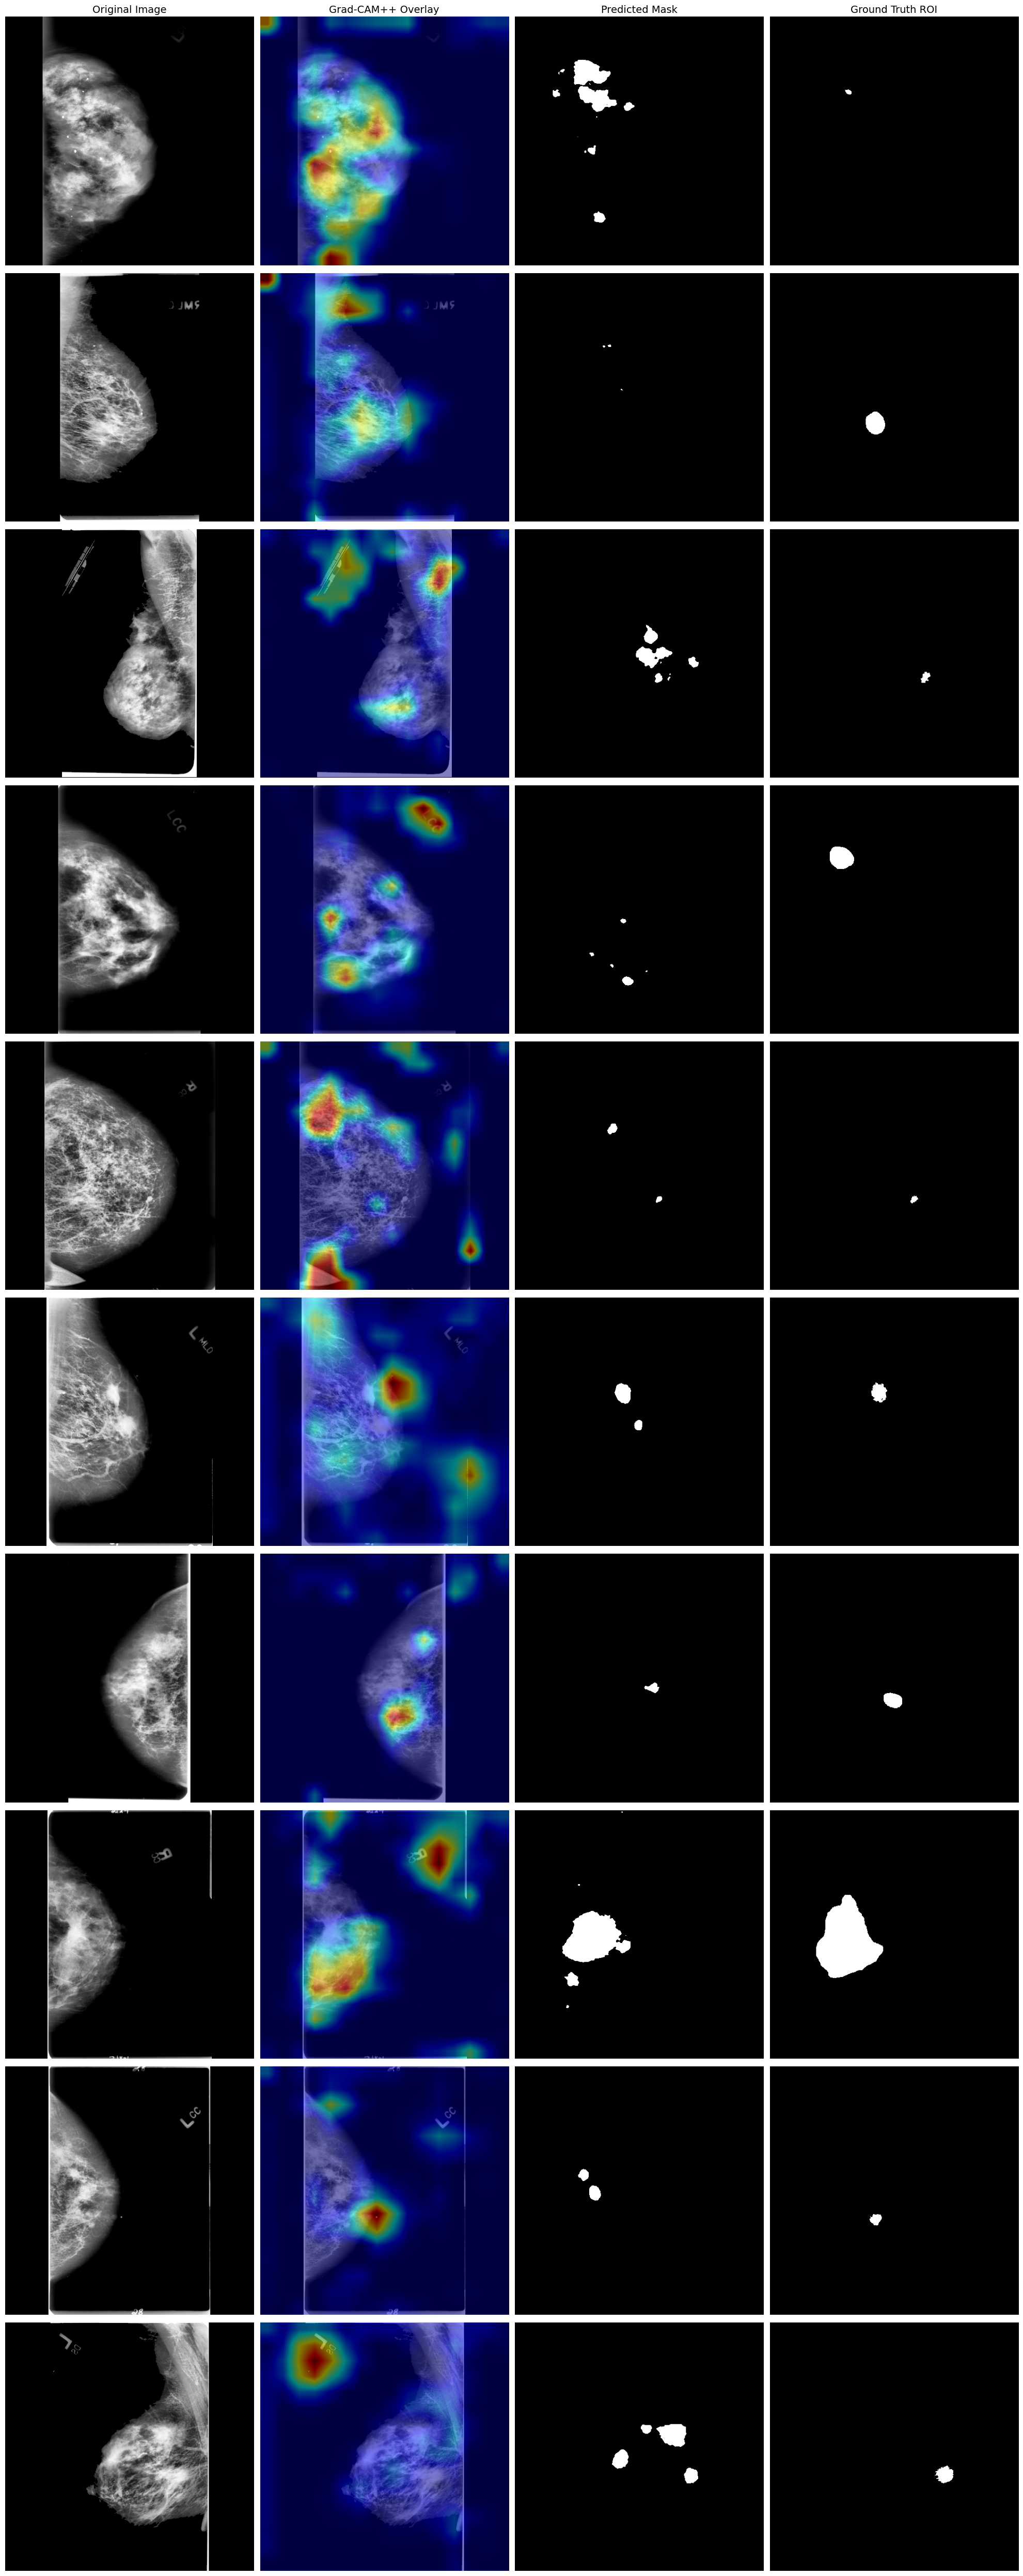


--- Diagnosis Summary ---
Average MGT Score: 0.0224 (Target: >0.80)
POOR: Model is not attending to lesion regions.
Likely cause: model learned shortcuts — check if heatmaps highlight edges, artifacts, or pectoral region.


In [10]:
!pip install grad-cam segmentation-models-pytorch monai timm -q

import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from monai.transforms import MapTransform, Compose, EnsureChannelFirstd
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- Configuration ---
DATA_DIR   = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1"
CSV_PATH   = "/kaggle/working/CBIS_Master_Index_Clean.csv"
MODEL_PATH = "/kaggle/working/best_model.pth"
RANDOM_SEED = 42


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


# ==============================================================================
# 1. Preprocessing Transforms (EXP-02)
# ==============================================================================

class ConditionalFlipd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        if "RIGHT" in d[self.id_key].upper():
            for key in self.keys:
                d[key] = cv2.flip(d[key], 1)
        return d


class PectoralRemovalMLOd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        if "_CC" in d[self.id_key].upper():
            return d
        for key in self.keys:
            img = d[key]
            img_8u = (img / 256).astype(np.uint8)
            _, binary = cv2.threshold(img_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            h, w = binary.shape
            flood_mask = np.zeros((h + 2, w + 2), np.uint8)
            cv2.floodFill(binary, flood_mask, (0, 0), 255)
            pectoral_mask = flood_mask[1:-1, 1:-1]
            d[key] = np.where(pectoral_mask == 1, 0, img)
        return d


class CLAHE16Bitd(MapTransform):
    def __init__(self, keys, clip_limit=4.0, tile_grid_size=(8, 8)):
        super().__init__(keys)
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = self.clahe.apply(d[key].astype(np.uint16))
        return d


class ForegroundZScored(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key].astype(np.float32)
            mask = img > 0
            if mask.sum() > 0:
                img[mask] = (img[mask] - img[mask].mean()) / (img[mask].std() + 1e-8)
            d[key] = img
        return d


preprocess_pipeline = Compose([
    ConditionalFlipd(keys=["image", "roi"]),
    PectoralRemovalMLOd(keys=["image"]),
    CLAHE16Bitd(keys=["image"]),
    ForegroundZScored(keys=["image"]),
    EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel"),
])


# ==============================================================================
# 2. Model Architecture (EXP-03/05)
# ==============================================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1     = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        mx  = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        return self.sigmoid(avg + mx)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx  = torch.max(x,  dim=1, keepdim=True)[0]
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, in_planes):
        super().__init__()
        self.ca = ChannelAttention(in_planes)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)  # channel attention first
        x = x * self.sa(x)  # spatial attention second
        return x


class MTL_EfficientUNetPlusPlus(nn.Module):
    def __init__(self):
        super().__init__()
        self.smp_base = smp.UnetPlusPlus(
            encoder_name="tu-tf_efficientnet_b0",
            encoder_weights=None,  # loading from checkpoint — no pretrained download needed
            in_channels=1,
            classes=1,
            activation=None,
        )
        bottleneck_ch = self.smp_base.encoder.out_channels[-1]
        self.classification_branch = nn.Sequential(
            CBAM(in_planes=bottleneck_ch),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(bottleneck_ch, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            # No sigmoid — trained with BCEWithLogitsLoss
            # Apply sigmoid manually at inference
        )

    def forward(self, x):
        features    = self.smp_base.encoder(x)
        seg_mask    = self.smp_base.segmentation_head(self.smp_base.decoder(features))
        class_score = self.classification_branch(features[-1])
        return seg_mask, class_score


# ==============================================================================
# 3. Grad-CAM Wrapper
# ==============================================================================

class ClassificationWrapper(nn.Module):
    """Isolates classification output for Grad-CAM backprop."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        _, class_score = self.model(x)
        return class_score


# ==============================================================================
# 4. Helper Functions
# ==============================================================================

def compute_mgt(heatmap, gt_mask):
    """
    MGT score: IoU between top 20% heatmap activations and ground truth ROI.
    Target > 0.80.
    """
    threshold      = np.percentile(heatmap, 80)
    binarized_heat = (heatmap >= threshold).astype(np.float32)
    gt_bin         = (gt_mask > 0).astype(np.float32)
    intersection   = np.logical_and(binarized_heat, gt_bin).sum()
    union          = np.logical_or(binarized_heat, gt_bin).sum()
    return float(intersection / (union + 1e-8))


def norm_for_display(img_tensor):
    """Converts Z-scored (1, H, W) tensor to normalized (H, W, 3) RGB for Grad-CAM overlay."""
    img      = img_tensor.squeeze().cpu().numpy()
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return np.stack([img_norm] * 3, axis=-1).astype(np.float32)


# ==============================================================================
# 5. Main
# ==============================================================================

def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using Device: {device}")

    # Load model
    model = MTL_EfficientUNetPlusPlus().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded successfully.")

    # Wrap for Grad-CAM
    cam_model    = ClassificationWrapper(model)
    target_layer = [model.smp_base.encoder.model.blocks[-1]]
    cam          = GradCAMPlusPlus(model=cam_model, target_layers=target_layer)

    # Sample 5 benign + 5 malignant from test set
    df         = pd.read_csv(CSV_PATH)
    test_df    = df[df['Patient_Split'] == 'Test']
    benign     = test_df[test_df['Label'] == 0].sample(5, random_state=RANDOM_SEED)
    malignant  = test_df[test_df['Label'] == 1].sample(5, random_state=RANDOM_SEED)
    sample_df  = pd.concat([benign, malignant]).reset_index(drop=True)

    mgt_scores = []
    fig, axes  = plt.subplots(10, 4, figsize=(20, 50))

    # Column headers
    for col, title in enumerate(["Original Image", "Grad-CAM++ Overlay", "Predicted Mask", "Ground Truth ROI"]):
        axes[0, col].set_title(title, fontsize=14)

    print("\n--- Running Grad-CAM++ Inference ---")

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        # Load images
        img_raw = cv2.imread(os.path.join(DATA_DIR, row['Full_Path']), cv2.IMREAD_UNCHANGED)
        roi_raw = cv2.imread(os.path.join(DATA_DIR, row['ROI_Path']),  cv2.IMREAD_UNCHANGED)

        if img_raw is None or roi_raw is None:
            print(f"WARNING: Could not load sample {idx}, skipping.")
            continue

        roi_raw = (roi_raw > 0).astype(np.float32)

        # Preprocess
        data_dict  = preprocess_pipeline({"image": img_raw, "roi": roi_raw, "patient_id": row['PatientID']})
        img_tensor = data_dict["image"].clone().detach().to(torch.float32).unsqueeze(0).to(device)
        roi_np     = data_dict["roi"].squeeze().numpy() if hasattr(data_dict["roi"], 'numpy') else data_dict["roi"].squeeze()

        # Forward pass
        with torch.no_grad():
            pred_mask_logits, pred_score_logits = model(img_tensor)
            pred_mask   = (torch.sigmoid(pred_mask_logits) > 0.5).squeeze().cpu().numpy().astype(np.float32)
            pred_score  = torch.sigmoid(pred_score_logits).item()

        # Grad-CAM++ — targets=None maximizes the classification output
        grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0]

        # MGT score
        mgt = compute_mgt(grayscale_cam, roi_np)
        mgt_scores.append(mgt)

        # Visualization
        rgb_img   = norm_for_display(img_tensor)
        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True, colormap=cv2.COLORMAP_JET)

        label_text = "Malignant" if row['Label'] == 1 else "Benign"
        pred_text  = "Malignant" if pred_score > 0.5 else "Benign"
        correct    = "✓" if (pred_score > 0.5) == bool(row['Label']) else "✗"

        axes[idx, 0].imshow(rgb_img, cmap='gray')
        axes[idx, 0].axis('off')
        axes[idx, 0].set_ylabel(f"GT: {label_text}\nPred: {pred_text} {correct}\nScore: {pred_score:.2f}", fontsize=9)

        axes[idx, 1].imshow(cam_image)
        axes[idx, 1].axis('off')
        axes[idx, 1].set_xlabel(f"MGT: {mgt:.3f}", fontsize=9)

        axes[idx, 2].imshow(pred_mask, cmap='gray')
        axes[idx, 2].axis('off')

        axes[idx, 3].imshow(roi_np, cmap='gray')
        axes[idx, 3].axis('off')

        print(f"[{idx+1}/10] {row['PatientID']} | GT: {label_text} | Pred: {pred_text} ({pred_score:.2f}) | MGT: {mgt:.3f}")

    plt.tight_layout()
    plt.savefig("gradcam_analysis.png", dpi=100, bbox_inches='tight')
    plt.show()

    # Summary
    avg_mgt = np.mean(mgt_scores)
    print(f"\n--- Diagnosis Summary ---")
    print(f"Average MGT Score: {avg_mgt:.4f} (Target: >0.80)")

    if avg_mgt >= 0.80:
        print("GOOD: Model is attending to correct lesion regions.")
    elif avg_mgt >= 0.50:
        print("PARTIAL: Model partially attends to lesion regions but is also distracted by other areas.")
        print("Likely cause: overfitting or mixed mass/calcification morphology confusing the encoder.")
    else:
        print("POOR: Model is not attending to lesion regions.")
        print("Likely cause: model learned shortcuts — check if heatmaps highlight edges, artifacts, or pectoral region.")


if __name__ == "__main__":
    main()